<a href="https://colab.research.google.com/github/Gpiratelo25/house-prices-explainable-ml/blob/main/estudo_houses_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.preprocessing import LabelEncoder
import os
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge

path=kagglehub.dataset_download('nabilabdul/ames-house-price-prediction-regression')

Using Colab cache for faster access to the 'ames-house-price-prediction-regression' dataset.


In [90]:
os.listdir(path)

['data_description.txt', 'data.csv']

In [91]:
with open(os.path.join(path,'data_description.txt'),'r') as f:
    print(f.read())

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

In [92]:
caminho_arquivo=os.path.join(path,'data.csv')


In [93]:
df=pd.read_csv(caminho_arquivo)

In [94]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [95]:
media_sale_price=df['SalePrice'].mean()
median_sale_price = df['SalePrice'].median()
moda_sale_price=df['SalePrice'].mode()

print(media_sale_price)
print(median_sale_price)
print(moda_sale_price)

180921.19589041095
163000.0
0    140000
Name: SalePrice, dtype: int64


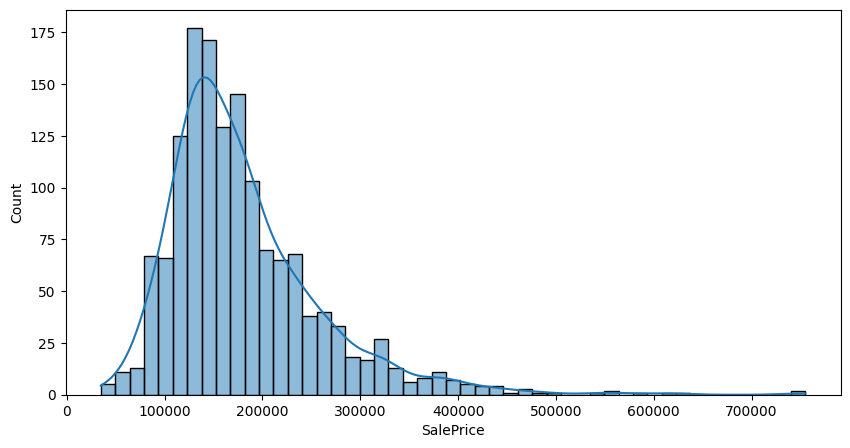

In [96]:
plt.figure(figsize=(10,5))
sns.histplot(df['SalePrice'],kde=True)
plt.show()

In [97]:
# Skewness (Assimetria):
# Mede a direção da cauda; >0 indica cauda longa à direita <0 à esquerda.
# Kurtosis (Curtose):
# Mede o achatamento e o peso das caudas,
# valores altos (>0) indicam forte presença de outliers (caudas grossas).
# Ambas ajudam a entender o comportamento e a normalidade da distribuição
# antes de aplicar transformações nos dados.

skew=df['SalePrice'].skew()
kurtosis=df['SalePrice'].kurtosis()

print('skew: ',skew)
print('kurtosis: ',kurtosis)

skew:  1.8828757597682129
kurtosis:  6.536281860064529


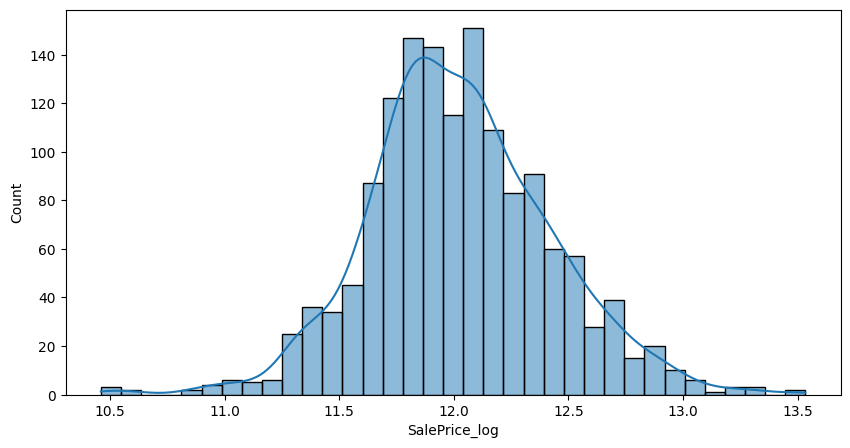

In [98]:
#aplicando a transformação logaritmica

df['SalePrice_log']=np.log1p(df['SalePrice'])
plt.figure(figsize=(10,5))
sns.histplot(df['SalePrice_log'],kde=True)
plt.show()

In [99]:
print('skew log',df['SalePrice_log'].skew())
print('Kurtosis log ',df['SalePrice_log'].kurtosis())

skew log 0.12134661989685333
Kurtosis log  0.809519155707878


In [100]:
X=df.drop(columns=['SalePrice_log','SalePrice'])

y=df['SalePrice_log']

In [101]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [102]:
X_train['Idade_Imovel'] = X_train['YrSold'] - X_train['YearBuilt']
X_train['Anos_Desde_Reforma'] = X_train['YrSold'] - X_train['YearRemodAdd']

X_test['Idade_Imovel'] = X_test['YrSold'] - X_test['YearBuilt']
X_test['Anos_Desde_Reforma'] = X_test['YrSold'] - X_test['YearRemodAdd']

In [103]:
# Calculamos a média do SalePrice_log POR BAIRRO usando APENAS o treino
mapeamento_bairros = y_train.groupby(X_train['Neighborhood']).mean().to_dict()

# Média global do treino para usar como fallback caso exista algum bairro exclusivo do teste
media_global_treino = y_train.mean()

In [104]:
X_train['Neighborhood_encoded'] = X_train['Neighborhood'].map(mapeamento_bairros).fillna(media_global_treino)
X_test['Neighborhood_encoded'] = X_test['Neighborhood'].map(mapeamento_bairros).fillna(media_global_treino)

# Agora podemos dropar a coluna original de texto
X_train.drop(columns=['Neighborhood'], inplace=True)
X_test.drop(columns=['Neighborhood'], inplace=True)

In [105]:
map_mszoning = {"FV": 4, "RL": 3, "RH": 2, "RM": 1, "C (all)": 0}
map_street = {'Grvl': 1, 'Pave': 2}
map_utilities = {'AllPub': 2, "NoSeWa": 1}
map_salecondition = {'Partial': 5, 'Normal': 4, 'Alloca': 3, 'Family': 2, 'Abnorml': 1, 'AdjLand': 0}

In [106]:
X_train['MSZoning'] = X_train['MSZoning'].map(map_mszoning).fillna(-1)
X_train['Street'] = X_train['Street'].map(map_street).fillna(-1)
X_train['Utilities'] = X_train['Utilities'].map(map_utilities).fillna(-1)
X_train['SaleCondition'] = X_train['SaleCondition'].map(map_salecondition).fillna(-1)

# Aplicamos EXATAMENTE IGUAL no X_test (Garantindo consistência produtiva)
X_test['MSZoning'] = X_test['MSZoning'].map(map_mszoning).fillna(-1)
X_test['Street'] = X_test['Street'].map(map_street).fillna(-1)
X_test['Utilities'] = X_test['Utilities'].map(map_utilities).fillna(-1)
X_test['SaleCondition'] = X_test['SaleCondition'].map(map_salecondition).fillna(-1)

In [107]:
colunas_object = X_train.select_dtypes(include=['object']).columns.tolist()

for col in colunas_object:
    le = LabelEncoder()
    # O Fit é feito APENAS no treino
    X_train[col] = le.fit_transform(X_train[col].astype(str))

    # O Teste apenas transforma (se houver categoria nova, tratamos o erro simulando produção)
    # Para evitar quebra com categorias inéditas no teste:
    mapeamento_le = dict(zip(le.classes_, le.transform(le.classes_)))
    X_test[col] = X_test[col].map(mapeamento_le).fillna(-1).astype(int)

In [108]:
X_train_final = X_train.fillna(X_train.median())
X_test_final = X_test.fillna(X_train.median()) # Fallback com a mediana do treino!

print("Features de Treino prontas:", X_train_final.shape)
print("Features de Teste prontas:", X_test_final.shape)

Features de Treino prontas: (1168, 82)
Features de Teste prontas: (292, 82)


In [109]:
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

In [110]:
modelo_glm = Ridge(alpha=1.0)
modelo_glm.fit(X_train_final, y_train)

Ridge()

In [111]:
modelo_boosting = LGBMRegressor(random_state=42, n_estimators=100, learning_rate=0.05, verbose=-1)
modelo_boosting.fit(X_train_final, y_train)

LGBMRegressor(learning_rate=0.05, random_state=42, verbose=-1)

In [112]:
pred_glm_log = modelo_glm.predict(X_test_final)
pred_boosting_log = modelo_boosting.predict(X_test_final)

In [113]:
y_test_real = np.expm1(y_test)
pred_glm_real = np.expm1(pred_glm_log)
pred_boosting_real = np.expm1(pred_boosting_log)

In [114]:
mae_glm = mean_absolute_error(y_test_real, pred_glm_real)
mae_boosting = mean_absolute_error(y_test_real, pred_boosting_real)

r2_glm = r2_score(y_test_real, pred_glm_real)
r2_boosting = r2_score(y_test_real, pred_boosting_real)

print(f"--- MODELO GLM (Ridge) ---")
print(f"Erro Médio Absoluto (MAE): ${mae_glm:,.2f}")
print(f"Poder de Explicação (R²): {r2_glm:.4f}\n")

print(f"--- MODELO MACHINE LEARNING (LightGBM) ---")
print(f"Erro Médio Absoluto (MAE): ${mae_boosting:,.2f}")
print(f"Poder de Explicação (R²): {r2_boosting:.4f}")

--- MODELO GLM (Ridge) ---
Erro Médio Absoluto (MAE): $81,728.36
Poder de Explicação (R²): -0.0617

--- MODELO MACHINE LEARNING (LightGBM) ---
Erro Médio Absoluto (MAE): $16,072.46
Poder de Explicação (R²): 0.8935


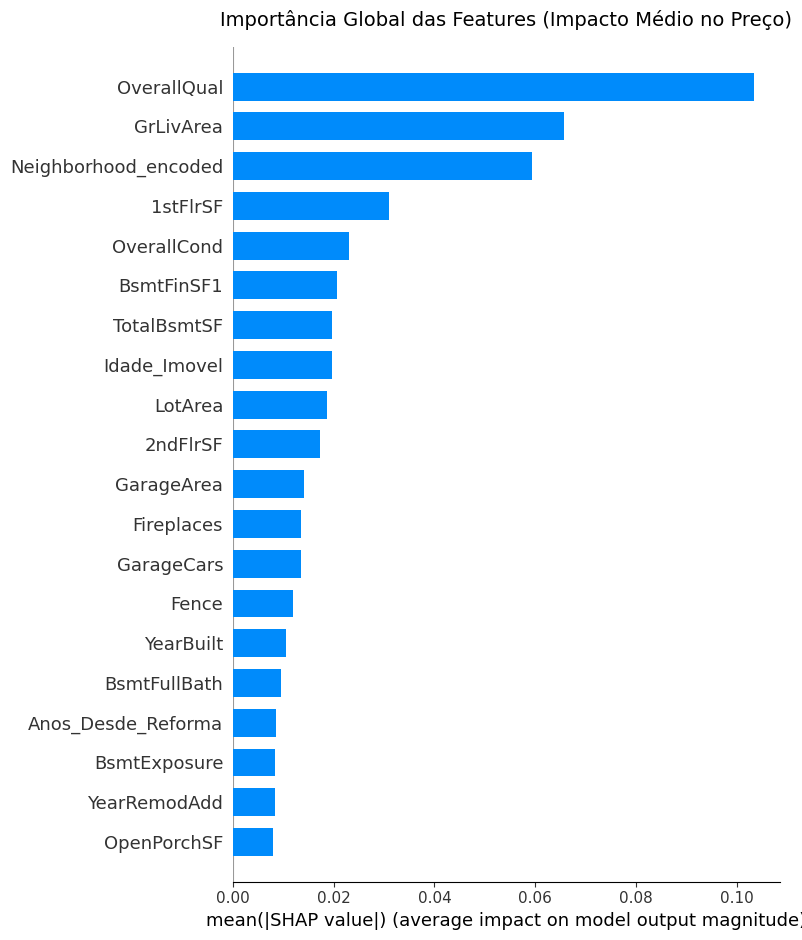

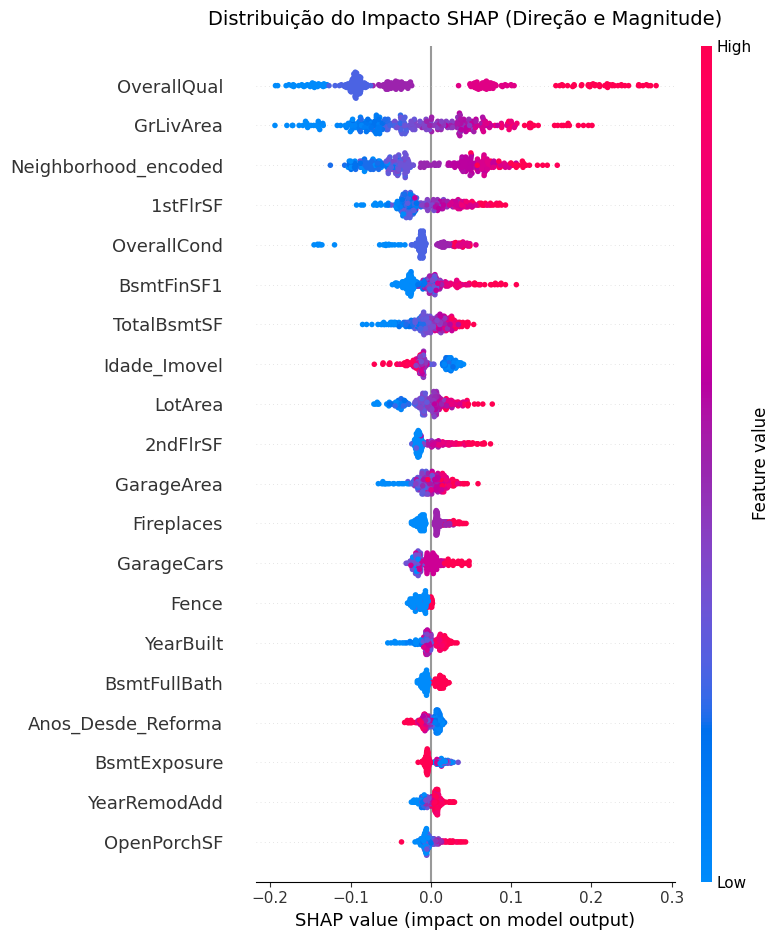

In [122]:
import shap
import matplotlib.pyplot as plt
explainer = shap.TreeExplainer(modelo_boosting_otimizado)
shap_values = explainer(X_test_final)

# =====================================================================
# VISUALIZAÇÃO GERAL: O Gráfico de Impacto Global (Summary Plot)
# =====================================================================
# Esse gráfico mostra a importância de cada variável e a direção do impacto.
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_final, plot_type="bar", show=False)
plt.title("Importância Global das Features (Impacto Médio no Preço)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# =====================================================================
# VISUALIZAÇÃO DETALHADA: Summary Plot de Distribuição (Beeswarm)
# =====================================================================
# O gráfico mais poderoso do SHAP. Ele mostra se valores altos/baixos da variável
# aumentam ou diminuem o preço do imóvel.
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_final, show=False)
plt.title("Distribuição do Impacto SHAP (Direção e Magnitude)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [120]:
import optuna
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np
import warnings

# O Optuna pode gerar muitos logs, vamos deixar apenas os avisos importantes
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

def objective(trial):
    # 1. Definir o espaço de busca dos hiperparâmetros (Dicionário de buscas)
    params = {
        'random_state': 42,
        'verbose': -1,
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 40),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0)
    }

    # 2. Validação Cruzada Robusta (5-Fold) para garantir estabilidade estatística
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse_scores = []

    for train_idx, val_idx in kf.split(X_train_final):
        X_tr, X_va = X_train_final.iloc[train_idx], X_train_final.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Criar e treinar o modelo com os parâmetros do "trial" atual
        model = LGBMRegressor(**params)
        model.fit(X_tr, y_tr)

        # Previsão na validação (Escala Log)
        preds = model.predict(X_va)
        rmse = np.sqrt(mean_squared_error(y_va, preds))
        rmse_scores.append(rmse)

    # O Optuna vai tentar MINIMIZAR a média do RMSE das 5 dobras
    return np.mean(rmse_scores)

# ==========================================
# EXECUÇÃO DA OTIMIZAÇÃO (STUDY)
# ==========================================
print("Iniciando a otimização com Optuna (20 tentativas)...")
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20) # Começamos com 20 trials para ser rápido

print("\n Otimização concluída!")
print(f"Melhor RMSE alcançado no treino: {study.best_value:.4f}")
print("Melhores hiperparâmetros encontrados:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

# ==========================================
# TREINAMENTO DO MODELO CAMPEÃO FINAL
# ==========================================
# Agora pegamos os melhores parâmetros e treinamos na base de treino COMPLETA
melhores_parametros = study.best_params
melhores_parametros['random_state'] = 42
melhores_parametros['verbose'] = -1

modelo_boosting_otimizado = LGBMRegressor(**melhores_parametros)
modelo_boosting_otimizado.fit(X_train_final, y_train)

# Previsões e avaliação final na escala de dinheiro (Dólares)
pred_otimizado_log = modelo_boosting_otimizado.predict(X_test_final)
pred_otimizado_real = np.expm1(pred_otimizado_log)
y_test_real = np.expm1(y_test)

mae_otimizado = mean_absolute_error(y_test_real, pred_otimizado_real)
r2_otimizado = r2_score(y_test_real, pred_otimizado_real)

print(f"\n--- LIGHTGBM OTIMIZADO VIA OPTUNA ---")
print(f"Erro Médio Absoluto Final (MAE): ${mae_otimizado:,.2f}")
print(f"Poder de Explicação Final (R²): {r2_otimizado:.4f}")

Iniciando a otimização com Optuna (20 tentativas)...

 Otimização concluída!
Melhor RMSE alcançado no treino: 0.1238
Melhores hiperparâmetros encontrados:
  - n_estimators: 292
  - learning_rate: 0.08777952915136283
  - max_depth: 5
  - num_leaves: 98
  - min_child_samples: 23
  - subsample: 0.9335914331116744
  - colsample_bytree: 0.6069716223213619

--- LIGHTGBM OTIMIZADO VIA OPTUNA ---
Erro Médio Absoluto Final (MAE): $16,205.59
Poder de Explicação Final (R²): 0.9018


In [119]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 18.6 MB/s eta 0:00:00


In [121]:
# Atualize a linha do explainer para o modelo otimizado
explainer = shap.TreeExplainer(modelo_boosting_otimizado)
shap_values = explainer(X_test_final)

# Execute os plots ( summary_plot de barras e beeswarm ) que passamos anteriormente